In [1]:
from typing import Annotated, NotRequired , Literal , Optional
from typing_extensions import TypedDict

from langchain_core.messages import ToolMessage
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState, create_react_agent
from langgraph.types import Command
from langchain_groq import ChatGroq

import os 
from langgraph.prebuilt.chat_agent_executor import AgentState
from langchain_google_genai import ChatGoogleGenerativeAI 

In [2]:

model = ChatGroq(
    model="llama-3.3-70b-versatile",   
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [5]:
TASK_DESCRIPTION_PREFIX = """Delegate a task to a specialized sub-agent with isolated context. Available agents for delegation are:
{other_agents}
"""

In [4]:
class SubAgent(TypedDict):
    name:str
    description:str
    prompt:str
    tools: NotRequired[list[str]]


def create_task_tool(tools, subagents:list[SubAgent] , model , state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

    This function implements the core pattern for spawning specialized sub-agents with
    isolated contexts, preventing context clash and confusion in complex multi-step tasks.

    Args:
        tools: List of available tools that can be assigned to sub-agents
        subagents: List of specialized sub-agent configurations
        model: The language model to use for all agents
        state_schema: The state schema (typically DeepAgentState)

    Returns:
        A 'task' tool that can delegate work to specialized sub-agents
    """

    agents ={}
    tools_by_name= {}

    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    for agent in subagents:
        if "tools" in agent:
            _tools = [tools_by_name[t] for t in agent["tools"]]
        else:
            _tools = tools
        agents[agent["name"]] = create_react_agent(
            model, prompt=agent["prompt"], tools=_tools, state_schema=state_schema
        )
    
    other_agents_string = [
        f"- {agent['name']}: {agent['description']}" for agent in subagents
    ]
    
    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str ,
        subagent_type :str ,
        state : Annotated[dict , InjectedState],
        tool_call_id :Annotated[dict , InjectedToolCallId]
    ):
        """Delegate a task to a specialized sub-agent with isolated context.

        This creates a fresh context for the sub-agent containing only the task description,
        preventing context pollution from the parent agent's conversation history.
        """        
        if subagent_type not in agents:
            return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"
        
        subagent=agents[subagent_type]

        state['messages']= [{'role':'user' , 'content':description}]

        result = subagent.invoke(state)

        return Command(
            update={
                "files": result.get("files", {}),  
                "messages": [
                    
                    ToolMessage(
                        result["messages"][-1].content, tool_call_id=tool_call_id
                    )
                ],
            }
        )
    return task




In [ ]:
SUBAGENT_USAGE_INSTRUCTIONS='''
                                                                                                              
│ <Task>                                                                                                          │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│     - description: Clear, specific research question or task                                                    │
│     - subagent_type: Type of agent to use (e.g., "research-agent")                                              │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│     - reflection: Your detailed reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element of the comparison:                                        │
│  - *Example*: "Compare OpenAI vs. Anthropic vs. DeepMind approaches to AI safety" → Use 3 sub-agents            │
│  - Store findings in separate files: `findings_openai_safety.md`, `findings_anthropic_safety.md`,               │
│  `findings_deepmind_safety.md`                                                                                  │
│                                                                                                                 │
│  **Multi-faceted research** can use parallel agents for different aspects:                                      │
│  - *Example*: "Research renewable energy: costs, environmental impact, and adoption rates" → Use 3 sub-agents   │
│  - Organize findings by aspect in separate files                                                                │
│                                                                                                                 │
│  **Important Reminders:**                                                                                       │
│  - Each **task** call creates a dedicated research agent with isolated context                                  │
│  - Sub-agents can't see each other's work - provide complete standalone instructions                            │
│  - Use clear, specific language - avoid acronyms or abbreviations in task descriptions                          │
│  </Scaling Rules> '''

In [36]:
# @tool(parse_docstring=True)
# def think_tool(reflection: str):
#     """Reflect on the results of each delegated task and plan next steps.

#     This tool is used for internal reflection and planning, and should not
#     be used to generate a final answer to the user.

#     Args:
#         reflection: Your detailed reflection on the results of the task and next steps.
#     """
#     # This tool doesn't need to return anything impactful to the state, 
#     # as the reflection itself is the output the model uses to plan.
#     return f"Reflection recorded: {reflection}"

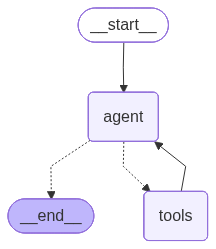

In [37]:
from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """You are a researcher. Research the topic provided to you. IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the provided topic."""

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}



# Tools for sub-agent
sub_agent_tools = [web_search]

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# Tools
delegation_tools = [task_tool , think_tool]
model_with_tools = model.bind_tools(delegation_tools)
# Create agent with system prompt
agent = create_react_agent(
    model_with_tools, 
    delegation_tools,
    prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %d, %Y").replace(" 0", " "),
    ),
    state_schema=DeepAgentState,
    reflect=False,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [38]:
# The fully initialized initial state input:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
        # Explicitly set the optional fields to their default initial values
        "todos": None,
        "files": None,
    }
)
for m in result['messages']:
    m.pretty_print()


BadRequestError: Error code: 400 - {'error': {'message': 'tool call validation failed: attempted to call tool \'task {"description": "Provide an overview of Model Context Protocol (MCP)", "subagent_type": "research-agent"}\' which was not in request.tools', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=task {"description": "Provide an overview of Model Context Protocol (MCP)", "subagent_type": "research-agent"}></function>'}}

: 

: 